## Number of eigenvalues of cell covariance matrix which follow power-law
Here, we calculate eigenspectra of cell covariance matrix.Thereafter, we plot the log(eigenvalues) versus log(rank of eigenvalue) and find out the number of eigenvalues n which fall on a power-law. 

In [1]:
#call necessary libraries
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import os #For file handling

#### Importing experimental scRNA-seq data

In [2]:
PATH = os.path.expanduser('~') + '/Dropbox/suvranil/cellmem'

In [3]:
#Input data is in gene-by-cell form
df = pd.read_csv(PATH + '/data/MemSeqData/HighVariable3000CountMatrix_batch_1.csv')
df

,gene,AAACGCTTCCGGACGT-1,AAAGGGCTCAGACAAA-1,AAAGTCCGTCCTCAGG-1,AAAGTGAGTGAGTGAC-1,AAAGTGAGTGTGCTTA-1,AAAGTGATCAAACGAA-1,AAATGGATCAAGTGTC-1,AACAAAGAGGCCCAAA-1,AACAACCCACAGTCGC-1,...,TTTGGAGCACCTGATA-4,TTTGGAGTCCTGGGAC-4,TTTGGAGTCTTAGTTC-4,TTTGGTTAGACGAGCT-4,TTTGGTTAGACTGAGC-4,TTTGGTTAGATTGGGC-4,TTTGGTTGTTGTATGC-4,TTTGTTGAGATGGCAC-4,TTTGTTGGTGTGATGG-4,TTTGTTGTCTGGTGCG-4
0,PRR9,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,DKK1,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,CCL5,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,OASL,0.000007,0.000013,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,PTGS2,0.000007,0.000000,0.000110,0.00000,0.0,0.0,0.0,0.000000,0.000009,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,ASB2,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000035,0.000037,0.000000
2996,SH3RF1,0.000000,0.000013,0.000022,0.00001,0.0,0.0,0.0,0.000000,0.000009,...,0.0,0.000000,0.0,0.000021,0.0,0.0,0.0,0.000000,0.000000,0.000000
2997,AL158835.1,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000027,0.000000,...,0.0,0.000033,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2998,HBQ1,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000017,0.000000,0.000019


In [4]:
df1 = df.iloc[: , 1 : ]
df1

,AAACGCTTCCGGACGT-1,AAAGGGCTCAGACAAA-1,AAAGTCCGTCCTCAGG-1,AAAGTGAGTGAGTGAC-1,AAAGTGAGTGTGCTTA-1,AAAGTGATCAAACGAA-1,AAATGGATCAAGTGTC-1,AACAAAGAGGCCCAAA-1,AACAACCCACAGTCGC-1,AACACACGTACCGGCT-1,...,TTTGGAGCACCTGATA-4,TTTGGAGTCCTGGGAC-4,TTTGGAGTCTTAGTTC-4,TTTGGTTAGACGAGCT-4,TTTGGTTAGACTGAGC-4,TTTGGTTAGATTGGGC-4,TTTGGTTGTTGTATGC-4,TTTGTTGAGATGGCAC-4,TTTGTTGGTGTGATGG-4,TTTGTTGTCTGGTGCG-4
0,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,0.000007,0.000013,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000031,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,0.000007,0.000000,0.000110,0.00000,0.0,0.0,0.0,0.000000,0.000009,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000016,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000035,0.000037,0.000000
2996,0.000000,0.000013,0.000022,0.00001,0.0,0.0,0.0,0.000000,0.000009,0.000000,...,0.0,0.000000,0.0,0.000021,0.0,0.0,0.0,0.000000,0.000000,0.000000
2997,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000027,0.000000,0.000016,...,0.0,0.000033,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2998,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000017,0.000000,0.000019


#### Eigenspectra of original cell covariance matrix (n)

In [5]:
#Converting gene-by-cell count matrix to cell-by-gene count matrix
z = df1.values.T
#centralization and normalization 
#This process should be done for each gene across all cells
X_E = np.float32((z - np.mean(z, axis = 0)) / np.std(z, axis = 0))
print('Shape of data matrix is: ', X_E.shape)
ng = X_E.shape[1] #number of genes
nc = X_E.shape[0] #number of cells

Shape of data matrix is:  (7590, 3000)


In [6]:
#Nonzero eigenevalues of XX^T and X^TX are same.
#We use this fact to reduce computation time ...
#by calculating covariance matrix of smaller size.
if nc <= ng:
    cv = np.matmul(X_E, X_E.T) / ng
else:
    cv = np.matmul(X_E.T, X_E) / ng
ev = np.linalg.eigvalsh(cv)[::-1]
rank = np.linspace(1, len(ev), len(ev)) 

#### Find the threshold
Here, we determine number of top eigenvalues that are following power-law by fitting a straight line to the log(eigenvalues) versus log(rank of eigenvalue) plot and checking the value of goodness of fit, R^2. As threshold increases, goodness of fit goes up initally within the power-law regime and then decreases. However, beyound a ceratin point after the power-law regime ends, goodness of fit increases again because of increased number of eigenvalues in the noisy region. Therefore, we choose the number of eigenvales around the first peak as the threshold here. 

But, we also note that some fluctuation n threshold value does not affect the end result (detecting memory genes) much. The details can be found [here](https://doi.org/10.1101/2025.01.15.633183) (in SI section). 

Text(0, 0.5, 'Eigenvalues')

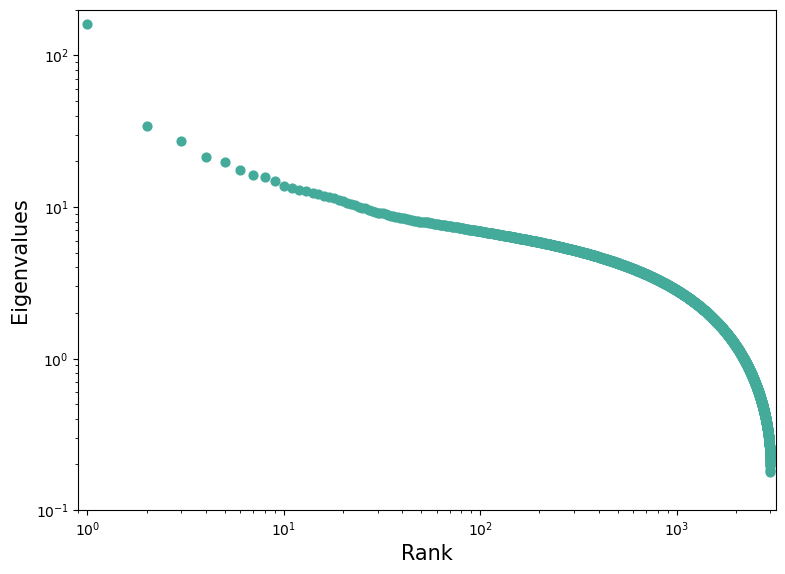

In [7]:
f = plt.figure(figsize=(9, 6.5), dpi = 100)
ax = f.add_subplot()
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(10**-1, 200)
ax.set_xlim(0.9, ng + 200)
ax.scatter(rank, ev,s = 40, color = '#44aa99', linewidth = 1.0)
ax.set_xlabel('Rank',fontsize=15)
ax.set_ylabel('Eigenvalues',fontsize=15)

In [8]:
initial_pt = 20 #It can be varied.
step = 5
rsquare_box = []
threshold_box = []
for i in range (initial_pt, min(ng, nc), step):
    #vary this threhold for desired R^2 value
    x_data = np.log(rank[: i])
    y_data = np.log(ev[: i])
    # fitting using linear regression
    result = stats.linregress(x_data, y_data)
    slope, intercept, r_val = result[0], result[1], result[2]
    rsquare_box.append(r_val**2)
    threshold_box.append(i)

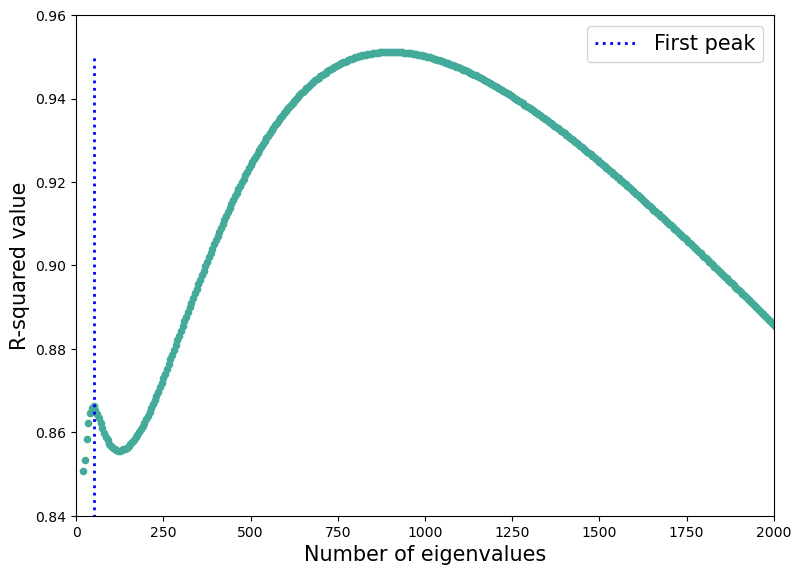

In [9]:
f = plt.figure(figsize=(9, 6.5), dpi = 100)
ax = f.add_subplot()
ax.set_ylim(0.84, 0.96)
ax.set_xlim(0, 2000)
ax.scatter(threshold_box, rsquare_box, s = 20, color = '#44aa99', linewidth = 1.0)
#we show first peak is around x = 50.
ax.plot([50, 50], [0.75, 0.95], linestyle = 'dotted', color = 'blue', linewidth = 2.0, 
        label= 'First peak')
ax.set_xlabel('Number of eigenvalues',fontsize=15)
ax.set_ylabel('R-squared value',fontsize=15)
ax.legend(fontsize = 15)

Here, we find that the first peak of the R^2-vs-number of eigenvales plot is around 50. So, the threshold (n) is 50. We have to use the **value of n as input** in PowerSeekAlgorithmOnData.ipynb file.

#### Implementation of Power-seq algorithm

In [10]:
#Threhold (n) is number of eigenvalues of original cell covariance ...
# matrix which follow a power-law. In 'FindThreshold.ipynb' ...
# file, we find value of threshold.
threshold = int(input())

In [11]:
delta_arr = np.zeros(ng)
if nc <=ng:
    for i in range (ng):
        #Removing a single gene
        X_E1 = np.delete(X_E, obj = i, axis = 1)
        #upadted covariance matrix
        cv1 = np.matmul(X_E1, X_E1.T) / (ng - 1)
        #Updated eigenspectra of cell covariance matrix
        ev1 = np.linalg.eigvalsh(cv1)[::-1]
        #Difference
        delta_arr[i] = np.sum(ev [ : threshold] - ev1[: threshold])
        del X_E1
else:
    for i in range (ng):
        #Removing a single gene
        X_E1 = np.delete(X_E, obj = i, axis = 1)
        #upadted covariance matrix
        cv1 = np.matmul(X_E1.T, X_E1) / (ng - 1)
        #Updated eigenspectra of cell covariance matrix
        ev1 = np.linalg.eigvalsh(cv1)[::-1]
        #Difference
        delta_arr[i] = np.sum(ev [: threshold] - ev1[: threshold])
        del X_E1

#### Detecting memory genes

In [12]:
#Power-Seq rank. Higher rank means lower memory timescale.
rank = delta_arr.argsort()[:: -1]
#vary highest_rank to get dfferent number of top rank memory genes
highest_rank = 500
PowerSeekGene = list(df.iloc[rank[0 : highest_rank], 0])